# Calibration for image acquisition

This notebook explores techniques to calibrate the image acquisition. In particular, here we deal with producing master flat- and dark-fields and how to process images by making use of these fields.

The techniques explored here follow lectures in astronomy by Michael Richmond, available in his educational [repository](http://spiff.rit.edu/classes/), particularly his [lecture](http://spiff.rit.edu/classes/phys445/lectures/darkflat/darkflat.html) on dark subtraction and flatfielding. Some sample images used here have been taken from Richmond's repository and converted to a normalized .tif file, as all his images are in .fit format. This was done with the python script `fit_to_tif.py` included in the `imaging` directory of this project.

Ok, so what we need to get rid of the instrumental artifacts in the images is to get a master dark frame and a master flat frame, each of which is obtained from several images. We will require

✅ A function to import the dark/flat frames and store them in a list,

🔲 A way of finding the median value of the images,

🔲 A way of finding the median value from all the images on a pixel-by-pixel basis,

🔲 To construct the master frames from these values,

🔲 To subtract the dark frame from each image and to "divide" each image by the flat frame.

#### Master dark frame:
-

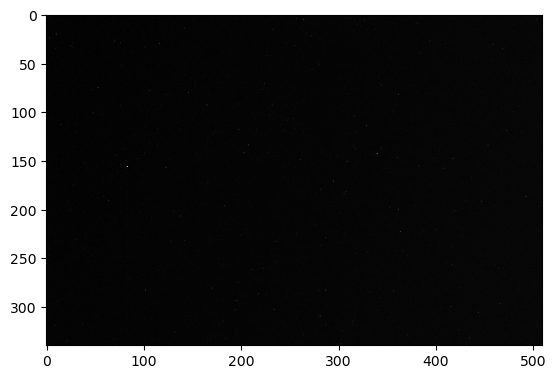

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io


DATA_DIR = '../data/richmond/'
files = ['dark4_001.tif','dark4_002.tif','dark4_003.tif','dark4_004.tif']

img = io.imread(DATA_DIR+files[0])
plt.imshow(img, cmap='grey')

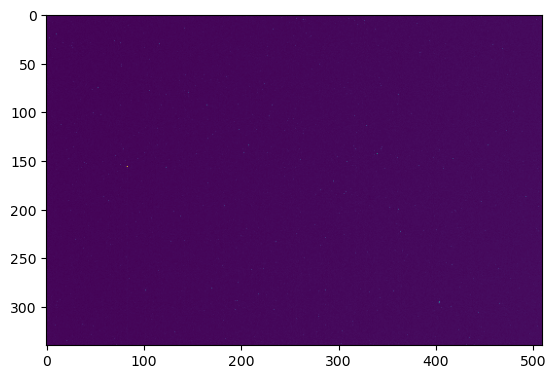

In [2]:
def import_images(files: list[str]) -> list[np.ndarray]:
    """
    Imports a list of image files and returns them as np.ndarray's
    
    Parameters
    ----------
    files : list[str]
        List of paths of the image files

    Returns
    -------
    list[np.ndarray]
        The images as arrays
    """

    return [io.imread(path) for path in files]

# Test here

fileList = [DATA_DIR + file for file in files]
frames = import_images(fileList)
plt.imshow(frames[2])

In [25]:
def median_pixel_basis(imgs: list[np.ndarray]) -> np.ndarray:
    """
    Determines the median value of a set of images, on a pixel by pixel basis.

    Parameters
    ----------
    imgs: list[np.ndarray]
        The images used to compute the median.

    Return
    ------
    np.ndarray
        An image whose pixels are the median values of the original images.
    """
    if not(all(im.shape==imgs[0].shape for im in imgs)):
        raise Exception('The images have different sizes.')

    original_shape = imgs[0].shape
    imgs = np.vstack([im.reshape((1,-1)) for im in imgs])
    return np.median(imgs, axis=0).reshape(original_shape)

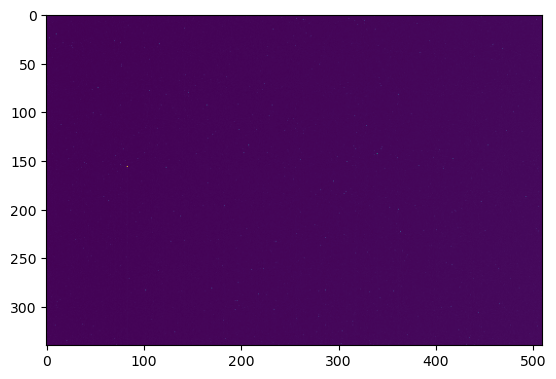

In [27]:
master_dark = median_pixel_basis(frames)
plt.imshow(master_dark)

In [3]:
frames[0].shape

(340, 510)

In [7]:
arr = np.array([[1,2,3,4],[5,6,7,8],[9,10,11,12]])
arr

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [10]:
arr.reshape(-1)

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12])

In [11]:
arr.reshape((3,-1))

array([[ 1,  2,  3,  4],
       [ 5,  6,  7,  8],
       [ 9, 10, 11, 12]])

In [12]:
np.median(arr)

6.5

In [19]:
np.median(arr, axis=[0])

array([5., 6., 7., 8.])

In [21]:
(9,9)==(9,10)

False

In [42]:
[arr[0,0] for arr in frames]

[0.08353337, 0.06478873, 0.08438409, 0.0741966]

In [43]:
np.median([arr[0,0] for arr in frames])

0.078864984

In [44]:
master_dark[0,0]

0.078864984